In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import csv
import kagglehub
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import random

In [2]:
def seed_everything(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [3]:
path = kagglehub.dataset_download("oddrationale/mnist-in-csv")

In [4]:
seed_everything(0)

train_x = list()
train_t = list()
with open(f"{path}/mnist_train.csv", "r") as f:
    reader = csv.reader(f)

    for i, L in enumerate(reader):
        if i == 0:
            print(L)
            continue

        L = list(map(float, L))
        input = L[1:]
        number = int(L[0])
        teacher_signal = [0] * 10
        teacher_signal[number] = 1

        train_x.append(input)
        train_t.append(teacher_signal)

train_x = torch.tensor(train_x, dtype=torch.float32)
train_t = torch.tensor(train_t, dtype=torch.float32)

# 平均と標準偏差を計算
mean_x = train_x.mean(dim=0, keepdim=True)
sd_x = (train_x - mean_x).pow(2).mean(dim=0, keepdim=True).pow(0.5)

# 標準化
train_x = (train_x - mean_x) / (sd_x + 1e-6)

['label', '1x1', '1x2', '1x3', '1x4', '1x5', '1x6', '1x7', '1x8', '1x9', '1x10', '1x11', '1x12', '1x13', '1x14', '1x15', '1x16', '1x17', '1x18', '1x19', '1x20', '1x21', '1x22', '1x23', '1x24', '1x25', '1x26', '1x27', '1x28', '2x1', '2x2', '2x3', '2x4', '2x5', '2x6', '2x7', '2x8', '2x9', '2x10', '2x11', '2x12', '2x13', '2x14', '2x15', '2x16', '2x17', '2x18', '2x19', '2x20', '2x21', '2x22', '2x23', '2x24', '2x25', '2x26', '2x27', '2x28', '3x1', '3x2', '3x3', '3x4', '3x5', '3x6', '3x7', '3x8', '3x9', '3x10', '3x11', '3x12', '3x13', '3x14', '3x15', '3x16', '3x17', '3x18', '3x19', '3x20', '3x21', '3x22', '3x23', '3x24', '3x25', '3x26', '3x27', '3x28', '4x1', '4x2', '4x3', '4x4', '4x5', '4x6', '4x7', '4x8', '4x9', '4x10', '4x11', '4x12', '4x13', '4x14', '4x15', '4x16', '4x17', '4x18', '4x19', '4x20', '4x21', '4x22', '4x23', '4x24', '4x25', '4x26', '4x27', '4x28', '5x1', '5x2', '5x3', '5x4', '5x5', '5x6', '5x7', '5x8', '5x9', '5x10', '5x11', '5x12', '5x13', '5x14', '5x15', '5x16', '5x17', '5x

In [5]:
seed_everything(0)

test_x = list()
test_t = list()
with open(f"{path}/mnist_test.csv", "r") as f:
    reader = csv.reader(f)

    for i, L in enumerate(reader):
        if i == 0:
            continue

        L = list(map(float, L))
        input = L[1:]
        number = int(L[0])
        teacher_signal = [0] * 10
        teacher_signal[number] = 1

        test_x.append(input)
        test_t.append(teacher_signal)

test_x = torch.tensor(test_x, dtype=torch.float32)
test_t = torch.tensor(test_t, dtype=torch.float32)

# 標準化
test_x = (test_x - mean_x) / (sd_x + 1e-6)

In [6]:
print(len(train_x), len(train_t))
print(len(test_x), len(test_t))

60000 60000
10000 10000


In [7]:
#全結合モデル
seed_everything(0)
class MyModel(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = torch.nn.Linear(784, 100)
        self.ReLU = torch.nn.ReLU()
        self.fc2 = torch.nn.Linear(100, 50)
        self.ReLU = torch.nn.ReLU()
        self.fc3 = torch.nn.Linear(50, 10)
        self.softmax1 = torch.nn.Softmax(dim = 1)

    def __call__(self, input:torch.tensor):

        Y = self.fc1(input)
        Y = self.ReLU(Y)
        Y = self.fc2(Y)
        Y = self.ReLU(Y)
        Y = self.fc3(Y)
        Y = self.softmax1(Y)

        return Y

model = MyModel()
model(train_x[:1])

tensor([[0.0882, 0.0985, 0.1096, 0.0934, 0.1100, 0.0747, 0.1039, 0.1132, 0.0984,
         0.1099]], grad_fn=<SoftmaxBackward0>)

In [8]:
LEARNING_RATE = 0.001
BATCH_SIZE = 512
EPOCHS = 50

In [9]:
#学習関数
seed_everything(0)
def loss_func(Y, T):
    E = ((-1.0 * T * torch.log(Y + 1e-6))).sum(dim=1).mean()
    return E

def accuracy_func(Y, T):
    Y = Y.argmax(dim=1)
    T = T.argmax(dim=1)
    A = (Y == T).float().mean()
    return A

def iteration(X_batch, T_batch, model, optimizer = None):

    # 学習する場合
    if optimizer is not None:
        optimizer.zero_grad()
        Y_batch = model(X_batch)
        E_batch = loss_func(Y_batch, T_batch)
        E_batch.backward()
        optimizer.step()

    # 学習しない場合
    else:
        with torch.no_grad():
            Y_batch = model(X_batch)
            E_batch = loss_func(Y_batch, T_batch)

    A_batch = accuracy_func(Y_batch, T_batch)

    return E_batch.item(), A_batch.item()

def epoch(X, T, model, optimizer = None):

    # 全データをランダムに並べ替える
    random_idx = torch.randperm(X.size(0))
    X = X[random_idx]
    T = T[random_idx]

    E = 0
    A = 0
    total_data = 0

    pb = tqdm(range(0, len(X), BATCH_SIZE))
    for idx in pb:

        # ミニバッチのデータを抽出
        X_batch = X[idx:idx + BATCH_SIZE]
        T_batch = T[idx:idx + BATCH_SIZE]

        E_batch, A_batch = iteration(X_batch, T_batch, model, optimizer)

        # ミニバッチの平均になっている誤差と精度を総和に戻す
        E += E_batch * len(X_batch)
        A += A_batch * len(X_batch)
        total_data += len(X_batch)

        pb.set_postfix({"loss": E / total_data,
                        "accuracy": A / total_data})

    # 全データでの平均の誤差と精度
    E /= total_data
    A /= total_data

    return E, A

In [10]:
#Schedule-Free_ADINAクラス
seed_everything(0)
class ScheduleFree_ADINA(torch.optim.Optimizer):
    def __init__(self, params, lr=LEARNING_RATE, lamda=0.3, beta1 =0.9, beta2 = 0.999, a = 0.1, b = 0.01, eps = 1e-8):
        defaults = {"lr":lr, "lamda":lamda, "beta1":beta1, "beta2":beta2, "a":a, "b":b, "eps":eps}
        super().__init__(params, defaults)
        self.train_mode = True

    def train(self):
        if not self.train_mode:
            for group in self.param_groups:
                lamda = group["lamda"]
                for p in group["params"]:
                    if p.grad is None:
                        continue
                    state = self.state[p]
                    p.data.copy_(state["w"])
                    p.data.lerp_(state["x"], lamda)
            self.train_mode = True

    def eval(self):
        if self.train_mode:
            for group in self.param_groups:
                for p in group["params"]:
                    if p.grad is None:
                        continue
                    state = self.state[p]
                    p.data.copy_(state["x"])
            self.train_mode = False

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            lr = group["lr"]
            lamda = group["lamda"]
            beta1 = group["beta1"]
            beta2 = group["beta2"]
            a = group["a"]
            b = group["b"]
            eps = group["eps"]
            for p in group["params"]:
                if p.grad is None:
                    continue
                state = self.state[p]
                if len(state) == 0:
                    state["w"] = p.data.clone()
                    state["x"] = p.data.clone()
                    state["g"] = torch.zeros_like(p.data)
                    state["v"] = torch.zeros_like(p.data)
                    state["k"] = 0

                state["k"] += 1
                k = state["k"]

                w = state["w"]
                x = state["x"]
                g = state["g"]
                v = state["v"]
                grad = p.grad

                g.mul_(beta1).add_(grad * ((1 - a*b) / a), alpha = 1.0 - beta1)
                v.mul_(beta2).add_(grad**2, alpha = 1.0 - beta2)
                w.sub_((g / (1 - beta1**(k+1)) + b * grad) / ((v / (1-beta2**(k+1)))**0.5 + eps), alpha = lr)
                x.lerp_(w, 1/(k+1))

                if self.train_mode:
                    p.data.copy_(w)
                    p.data.lerp_(x, lamda)
                else:
                    p.data.copy_(x)

        return loss

In [11]:
#Schedule-Free_ADINA
seed_everything(0)
model = MyModel()
optimizer = ScheduleFree_ADINA(model.parameters(), lr = LEARNING_RATE)
loss_func = loss_func

SF_ADINA_train_loss_history = list()
SF_ADINA_test_loss_history = list()
SF_ADINA_train_acuracy_history = list()
SF_ADINA_test_acuracy_history = list()

# 初期評価（evalモード）
optimizer.eval()
E, A = epoch(train_x, train_t, model)
SF_ADINA_train_loss_history.append(E)
SF_ADINA_train_acuracy_history.append(A)

E, A = epoch(test_x, test_t, model)
SF_ADINA_test_loss_history.append(E)
SF_ADINA_test_acuracy_history.append(A)

for i in range(EPOCHS):
    print(f"epoch; {i + 1}")

    #学習
    optimizer.train()
    E, A = epoch(train_x, train_t, model, optimizer)
    SF_ADINA_train_loss_history.append(E)
    SF_ADINA_train_acuracy_history.append(A)

    #評価
    optimizer.eval()
    E, A = epoch(test_x, test_t, model)
    SF_ADINA_test_loss_history.append(E)
    SF_ADINA_test_acuracy_history.append(A)

100%|██████████| 20/20 [00:00<00:00, 33.60it/s, loss=2.31, accuracy=0.108]


epoch; 1


100%|██████████| 20/20 [00:00<00:00, 21.91it/s, loss=0.153, accuracy=0.955]


epoch; 2


100%|██████████| 20/20 [00:00<00:00, 30.71it/s, loss=0.114, accuracy=0.967]


...

100%|██████████| 20/20 [00:00<00:00, 221.27it/s, loss=0.193, accuracy=0.978]


epoch; 49


100%|██████████| 20/20 [00:00<00:00, 30.45it/s, loss=0.195, accuracy=0.978]


epoch; 50


100%|██████████| 20/20 [00:00<00:00, 59.99it/s, loss=0.196, accuracy=0.978]


In [12]:
round(max(SF_ADINA_test_acuracy_history)*100,2)

97.87

In [13]:
#Adam
seed_everything(0)
model = MyModel()
optimizer = torch.optim.Adam(model.parameters(), lr = LEARNING_RATE, betas = (0.9, 0.999), eps = 1e-8)
loss_func = loss_func

Adam_train_loss_history = list()
Adam_test_loss_history = list()
Adam_train_acuracy_history = list()
Adam_test_acuracy_history = list()

E, A = epoch(train_x, train_t, model)
Adam_train_loss_history.append(E)
Adam_train_acuracy_history.append(A)
E, A = epoch(test_x, test_t, model)
Adam_test_loss_history.append(E)
Adam_test_acuracy_history.append(A)

for i in range(EPOCHS):
    print(f"epoch; {i + 1}")
    E, A = epoch(train_x, train_t, model, optimizer)
    Adam_train_loss_history.append(E)
    Adam_train_acuracy_history.append(A)

    E, A = epoch(test_x, test_t, model)
    Adam_test_loss_history.append(E)
    Adam_test_acuracy_history.append(A)

100%|██████████| 20/20 [00:00<00:00, 45.32it/s, loss=2.31, accuracy=0.108]


epoch; 1


100%|██████████| 20/20 [00:00<00:00, 87.04it/s, loss=0.212, accuracy=0.935]


epoch; 2


100%|██████████| 20/20 [00:00<00:00, 22.40it/s, loss=0.155, accuracy=0.953]


...

100%|██████████| 20/20 [00:00<00:00, 294.89it/s, loss=0.155, accuracy=0.975]


epoch; 49


100%|██████████| 20/20 [00:00<00:00, 28.51it/s, loss=0.157, accuracy=0.974]


epoch; 50


100%|██████████| 20/20 [00:00<00:00, 67.82it/s, loss=0.156, accuracy=0.974]


In [14]:
#ADINA
class ADINA(torch.optim.Optimizer):
    def __init__(self, params, lr = 0.001, beta_1 = 0.9, beta_2 = 0.9, a = 0.1, b = 0.01, c = 1):
        defaults = {"lr":lr, "beta_1":beta_1, "beta_2":beta_2, "a":a, "b":b}
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            lr = group["lr"]
            beta_1 = group["beta_1"]
            beta_2 = group["beta_2"]
            a = group["a"]
            b = group["b"]

            for w in group["params"]:
                if w.grad is None:
                    continue

                state = self.state[w]
                if len(state) == 0:
                    state["m"] = torch.zeros_like(w)
                    state["g"] = torch.zeros_like(w)
                    state["v"] = torch.zeros_like(w)
                    state["step"] = 0
                state["step"] += 1
                grad = w.grad
                m = state["m"]
                v = state["v"]
                step = state["step"]

                m.mul_(beta_1).add_(grad * (1-a*b) / a , alpha = 1.0 - beta_1)
                g = m / (1 - beta_1 ** step) + b * grad
                v.mul_(beta_2).add_(g*g , alpha = 1 - beta_2)
                w.sub_(g / (v / (1 - beta_2 ** step) + 1e-8)**0.5 , alpha = lr)

seed_everything(0)
model = MyModel()
optimizer = ADINA(model.parameters(), lr = LEARNING_RATE, beta_1 = 0.9, beta_2 = 0.9, a = 0.1, b = 0.01, c = 1)
loss_func = loss_func

ADINA_train_loss_history = list()
ADINA_test_loss_history = list()
ADINA_train_acuracy_history = list()
ADINA_test_acuracy_history = list()

E, A = epoch(train_x, train_t, model)
ADINA_train_loss_history.append(E)
ADINA_train_acuracy_history.append(A)
E, A = epoch(test_x, test_t, model)
ADINA_test_loss_history.append(E)
ADINA_test_acuracy_history.append(A)

for i in range(EPOCHS):
    print(f"epoch; {i + 1}")
    E, A = epoch(train_x, train_t, model, optimizer)
    ADINA_train_loss_history.append(E)
    ADINA_train_acuracy_history.append(A)

    E, A = epoch(test_x, test_t, model)
    ADINA_test_loss_history.append(E)
    ADINA_test_acuracy_history.append(A)

100%|██████████| 20/20 [00:00<00:00, 23.28it/s, loss=2.31, accuracy=0.108]


epoch; 1


100%|██████████| 20/20 [00:00<00:00, 25.11it/s, loss=0.175, accuracy=0.949]


epoch; 2


100%|██████████| 20/20 [00:00<00:00, 590.85it/s, loss=0.141, accuracy=0.962]


...

100%|██████████| 20/20 [00:00<00:00, 620.67it/s, loss=0.301, accuracy=0.971]


epoch; 49


100%|██████████| 20/20 [00:00<00:00, 732.35it/s, loss=0.29, accuracy=0.971]


epoch; 50


100%|██████████| 20/20 [00:00<00:00, 914.55it/s, loss=0.288, accuracy=0.971]


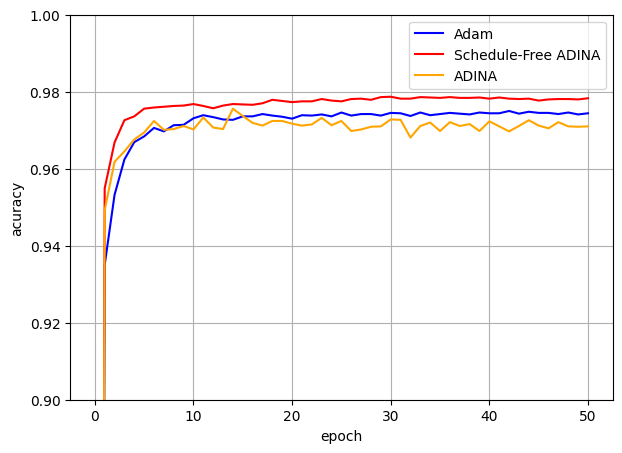

In [ ]:
fig = plt.figure(figsize = (7, 5))
ax = fig.add_subplot()
ax.plot(Adam_test_acuracy_history, label = "Adam", c = "blue")
ax.plot(SF_ADINA_test_acuracy_history, label = "Schedule-Free ADINA", c = 'red')
ax.plot(ADINA_test_acuracy_history, label = "ADINA", c = 'orange')
ax.set_xlabel("epoch")
ax.set_ylabel("acuracy")
ax.set_ylim([0.90,1])
ax.grid()
ax.legend()

式のアルゴリズムをパワポに書く